# Traffic analysis

Read and process PCAPs recorded during AI agent execution, provide basic statistics.

In [1]:
import pandas as pd
import os
import pcap_tools as pt
from pathlib import Path
import random
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

SAVE_DIR = "../results/plots/"
SAVE_PLOTS = True

AGENT_TYPE = "no-tools_random"  # weather_agent, no-tools_agent
SET_TYPE = "test"  # train, test
PCAP_DIR = f"/Users/tarik/data/{AGENT_TYPE}_{SET_TYPE}/pcap/"
CLIENT_IP = "172.17.0.2"

In [2]:
sns.set_theme(
    style="whitegrid",
    context="paper",   # or "notebook"
    font_scale=1.0
)

## Volume, latency

In [ ]:
results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/tarik/data/", f"{prompt}_agent_train/pcap")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    
    files = files[:300]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = pt.extract_agent_from_filename(p.name)
        analysis = pt.analyze_pcap(p, client_ip = CLIENT_IP)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt
        results.append(analysis)

results_df = pd.DataFrame(results)

In [ ]:
def boxplot_y(y):
    """
    Create two separate figures (same height) for:
      - no-tools and weather shown side-by-side (hue='prompt')
      - research alone
    Requires results_df, sns, plt, SAVE_PLOTS, SAVE_DIR to be available in the notebook.
    """
    if y not in results_df.columns:
        raise ValueError(f"Column '{y}' not found in results_df")

    order = sorted(results_df["backend"].unique())
    box_width = 0.6
    height = 5
    figsize = (8, height)

    first_prompts = ["no-tools", "weather"]
    second_prompts = ["research"]

    subset1 = results_df[results_df["prompt"].isin(first_prompts)]
    subset2 = results_df[results_df["prompt"].isin(second_prompts)]

    if y == "latency":
        y_label = "Latency [s]"
    elif y == "sent":
        y_label = "Data Sent [kB]"
    elif y == "received":
        y_label = "Data Received [kB]"
    elif y == "streams":
        y_label = "# TCP streams"
    else:
        y_label = y

    # Figure 1: no-tools and weather side-by-side using hue
    fig1, ax1 = plt.subplots(figsize=(5,4))
    if not subset1.empty:
        sns.boxplot(data=subset1, x="backend", y=y, hue="prompt", order=order,
                    width=box_width, palette="Set2", ax=ax1)
        #ax1.set_title("no-tools vs weather")
        ax1.set_xlabel(None)
        ax1.set_ylabel(y_label)
        #ax1.set_ylim(ylim)
        ax1.grid(axis="y", alpha=0.3)
        ax1.legend(title="Agent")
    else:
        ax1.text(0.5, 0.5, "No data for no-tools/weather", ha="center")
    fig1.tight_layout()
    if SAVE_PLOTS:
        fig1.savefig(f"{SAVE_DIR}boxplot_{y}_no-tools_weather.png", dpi=300)
    plt.show()

    # Figure 2: research only
    fig2, ax2 = plt.subplots(figsize=(3,4))
    if not subset2.empty:
        sns.boxplot(data=subset2, x="backend", y=y, order=order,
                    width=box_width, ax=ax2)
        #ax2.set_title("research")
        ax2.set_xlabel(None)
        ax2.set_ylabel(y_label)
        #ax2.set_ylim(ylim)
        ax2.grid(axis="y", alpha=0.3)
        ax2.legend(title="Agent", labels=["research"])
    else:
        ax2.text(0.5, 0.5, "No data for research", ha="center")
    fig2.tight_layout()
    if SAVE_PLOTS:
        fig2.savefig(f"{SAVE_DIR}boxplot_{y}_research.png", dpi=300)
    plt.show()

In [ ]:
boxplot_y("sent")
boxplot_y("received")
boxplot_y("latency")
boxplot_y("streams")

In [ ]:
plt.figure(figsize=(8,5))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=results_df, x="backend", y="sent", hue="prompt", palette="Set2", ax=axes[0])
axes[0].set_title("Bytes Sent")
axes[0].set_xlabel("Agent Backend")
axes[0].set_ylabel("Bytes sent [kB]")
axes[0].grid(axis="y", alpha=0.3)

sns.boxplot(data=results_df, x="backend", y="received", hue="prompt", palette="Set2", ax=axes[1])
axes[1].set_title("Bytes Received")
axes[1].set_xlabel("Agent Backend")
axes[1].set_ylabel("Bytes received [kB]")
axes[1].grid(axis="y", alpha=0.3)


## Burstiness

Analyze traffic burst:
- the number
- burst duration
- distribution within defined intervals

In [3]:
WINDOW_SIZE = 0.01  # seconds
MAX_MATRIX_LEN = 18000  # max number of windows in MTAM

results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/tarik/data/", f"{prompt}_agent_train/pcap")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    files = files[:100]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = pt.extract_agent_from_filename(p.name)
        packet_trace = pt.pcap_to_trace_scapy(str(p), client_ip = CLIENT_IP)
        analysis = pt.burst_analysis(packet_trace)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt

        # Reuse mtam for short burst analysis
        mtam = pt.build_mtam(packet_trace, window_size=WINDOW_SIZE, num_windows=MAX_MATRIX_LEN)
        window_bursts = pt.window_bursts(mtam)
        analysis["window_bursts"] = window_bursts
        results.append(analysis)


burst_df = pd.DataFrame(results)

Processing /Users/tarik/data/no-tools_agent_train/pcap:  13%|█▎        | 13/100 [00:00<00:00, 120.58it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (25 out of 36)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 43)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (23 out of 40)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 39)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (29 out of 44)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (25 out of 42)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (25 out of 34)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (31 out of 42)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (31 out of 45)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (29 out of 40)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 42)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (32 out

Processing /Users/tarik/data/no-tools_agent_train/pcap:  39%|███▉      | 39/100 [00:00<00:00, 121.72it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (24 out of 37)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 41)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 48)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 42)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (31 out of 46)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 45)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (24 out of 35)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (32 out of 44)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 43)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (24 out of 41)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 41)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (25 out

Processing /Users/tarik/data/no-tools_agent_train/pcap:  65%|██████▌   | 65/100 [00:00<00:00, 116.15it/s]

...

Processing /Users/tarik/data/research_agent_train/pcap:  97%|█████████▋| 97/100 [00:14<00:00,  6.37it/s]

*** Warning: trace length exceeds num_windows (23047 > 18000)


Processing /Users/tarik/data/research_agent_train/pcap:  98%|█████████▊| 98/100 [00:14<00:00,  5.18it/s]

*** Warning: trace length exceeds num_windows (18122 > 18000)


Processing /Users/tarik/data/research_agent_train/pcap: 100%|██████████| 100/100 [00:15<00:00,  6.51it/s]


### Prepare for plotting

- Explode the bursts

In [4]:
# One row per burst
df_scatter_plot = burst_df.explode("bursts", ignore_index=True)

# Split tuple into columns
df_scatter_plot[["size", "duration"]] = pd.DataFrame(
    df_scatter_plot["bursts"].tolist(),
    index=df_scatter_plot.index
)

# Readability: drop unneeded columns
df_scatter_plot = df_scatter_plot.drop(columns=["bursts", "datetime", "window_bursts", "avg_burst_size", "avg_burst_duration"])
df_scatter_plot = df_scatter_plot.rename(columns={
    "backend": "Model",
    "prompt": "Prompt",
})

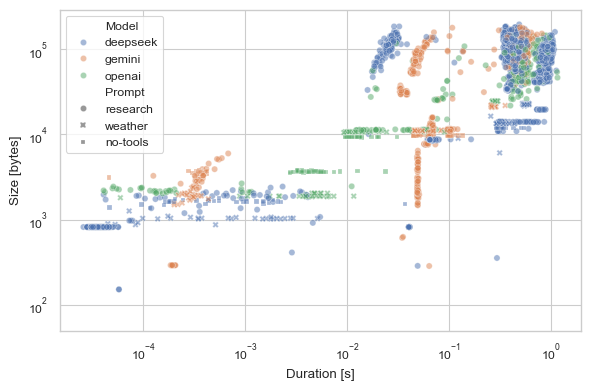

In [10]:
df_scatter_plot = df_scatter_plot.sample(frac=1, random_state=42)

plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df_scatter_plot,
    x="duration",
    y="size",
    hue="Model",
    style="Prompt",
    s = 20,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Duration [s]")
plt.ylabel("Size [bytes]")
plt.title(None) # "Burst Size vs Duration (colored by model and prompt)")
plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(f"{SAVE_DIR}burst_size_vs_duration.png", dpi=300)
plt.show()

In [6]:
df_window_plot = burst_df.explode("window_bursts", ignore_index=True)

df_window_plot["burst_bw"] = df_window_plot["window_bursts"] / WINDOW_SIZE *8 / 1024/1024  # in MB/s

# Readability: drop unneeded columns
df_window_plot = df_window_plot.drop(columns=["bursts", "datetime", "window_bursts", "avg_burst_size", "avg_burst_duration"])
df_window_plot = df_window_plot.rename(columns={
    "backend": "Model",
    "prompt": "Prompt",
})

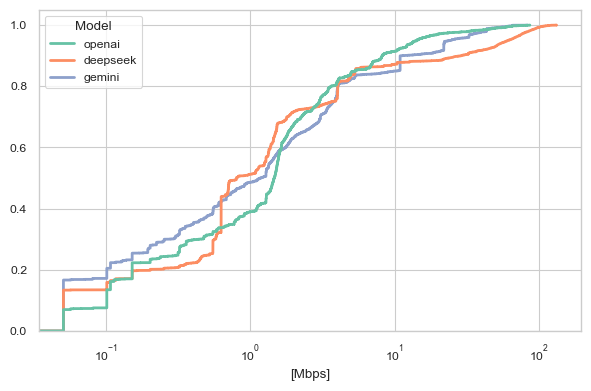

In [8]:
plt.figure(figsize=(6, 4))

sns.ecdfplot(
    data=df_window_plot,
    x="burst_bw",
    hue="Model", 
    palette="Set2",
    linewidth=2
)

plt.xscale("log")
plt.ylim(0, 1.05)

plt.xlabel("[Mbps]")
plt.ylabel(None)

#plt.title("Empirical CDF of burst bandwidth by backend")

#plt.legend(title="Backend")

plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig(f"{SAVE_DIR}burst_bandwidth_cdf_by_backend.png", dpi=300)
plt.show()